# Data Understanding 

## Initial Data Loading

To understand the data we're working with, our first step was loading the dataset.

## Data Source

**Primary Source:** https://automobile.tn

## Data Collection Scope

We conducted comprehensive web scraping of:

### New Vehicles
- All available new car listings
- Complete specifications and features

### Used Vehicles  
- All listed pre-owned cars
- Complete specifications and features


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load data
df_new = pd.read_csv("../data_scraper/data_scraped/automobileTnNew.csv")

df_used = pd.read_csv("../data_scraper/data_scraped/automobileTnUsed.csv")


first let's check the structure/dimensions of the data we're dealing with along with some general informations 

In [18]:
print("=== NEW CARS DATASET ===")
print(f"Shape: {df_new.shape}")
print("\nInfo:")
print(df_new.info())
print("\nFirst few rows:")
print(df_new.head())

print("\n=== USED CARS DATASET ===")
print(f"Shape: {df_used.shape}")
print("\nInfo:")
print(df_used.info())
print("\nFirst few rows:")
print(df_used.head())

=== NEW CARS DATASET ===
Shape: (510, 166)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Columns: 166 entries, URL to Cylindrée
dtypes: float64(33), int64(1), object(132)
memory usage: 661.5+ KB
None

First few rows:
                                                 URL  Brand   Model  \
0  https://www.automobile.tn/fr/neuf/skoda/fabia/...  skoda   fabia   
1  https://www.automobile.tn/fr/neuf/skoda/fabia/...  skoda   fabia   
2  https://www.automobile.tn/fr/neuf/skoda/fabia/...  skoda   fabia   
3  https://www.automobile.tn/fr/neuf/skoda/kushaq...  skoda  kushaq   
4  https://www.automobile.tn/fr/neuf/skoda/kushaq...  skoda  kushaq   

                  Option    Price Temps de recharge normale (AC) Peinture  \
0      1.0-l-mpi-essence  66 980                             NaN      NaN   
1    1.0-l-mpi-selection  72 980                             NaN      NaN   
2  1.0-l-mpi-monte-carlo  85 980                             NaN      NaN   
3       1.0-tsi

now we'll check for basic stats , column names , and missing values

In [19]:
# Check for missing values
print("\n=== MISSING VALUES ===")
print("New cars - Missing values:")
print(df_new.isnull().sum().sort_values(ascending=False))
print("\nUsed cars - Missing values:")
print(df_used.isnull().sum().sort_values(ascending=False))

# Basic statistics
print("\n=== BASIC STATISTICS ===")
print("New cars - Description:")
print(df_new.describe(include='all'))
print("\nUsed cars - Description:")
print(df_used.describe(include='all'))

# Check column names to understand the features
print("\n=== COLUMNS ===")
print("New cars columns:", df_new.columns.tolist())
print("Used cars columns:", df_used.columns.tolist())



=== MISSING VALUES ===
New cars - Missing values:
4 roues directrices            510
Voiture populaire              510
Anti-démarrage électronique    510
ABS                            510
Fixations ISOFIX               510
                              ... 
Energie                          0
Largeur                          0
Transmission                     0
Carrosserie                      0
URL                              0
Length: 166, dtype: int64

Used cars - Missing values:
État général                                    53
Anciens propriétaires                           39
URL                                              0
Intérieurs - Boîte à gants réfrigérée            0
Spécifications - Carrosserie                     0
                                                ..
Fonctionnels - Allumage automatique des feux     0
Extérieurs - Caméras 360                         0
Intérieurs - Accoudoir arrière                   0
Date de l'annonce                                0

# Data Quality Assessment & Analysis Plan

## New Cars Dataset Issues

### Data Completeness Problems
- **Multiple columns contain significant missing data**
- **Many columns are almost entirely empty**
- **Most columns have very few values populated**
- *Note: Will address these during data preparation phase*

### Data Type Issues
- **Pricing data is currently in string format**
- **Action required: Convert pricing to numeric format for analysis**

## Used Cars Dataset Statistics

### Price Distribution Summary
- **Mean Price:** 93,730 TND
- **Minimum Price:** 1,111 TND  
- **Maximum Price:** 720,000 TND
- *Indicates wide price range across used vehicle inventory*

## Analysis Strategy

### Focus on Key Metrics
- **Avoid column overload** - too many columns can overwhelm analysis
- **Stick to main data points** for statistical overview
- **Prioritize columns with sufficient data quality**

# Used Cars Visualizations

## Brands
- Brand distribution

## Body Types
- Car body type distribution

## Fuel Types  
- Fuel type distribution

## Transmission
- Transmission type distribution

## Year
- Vehicle year distribution

## Prices
- Prices distribution


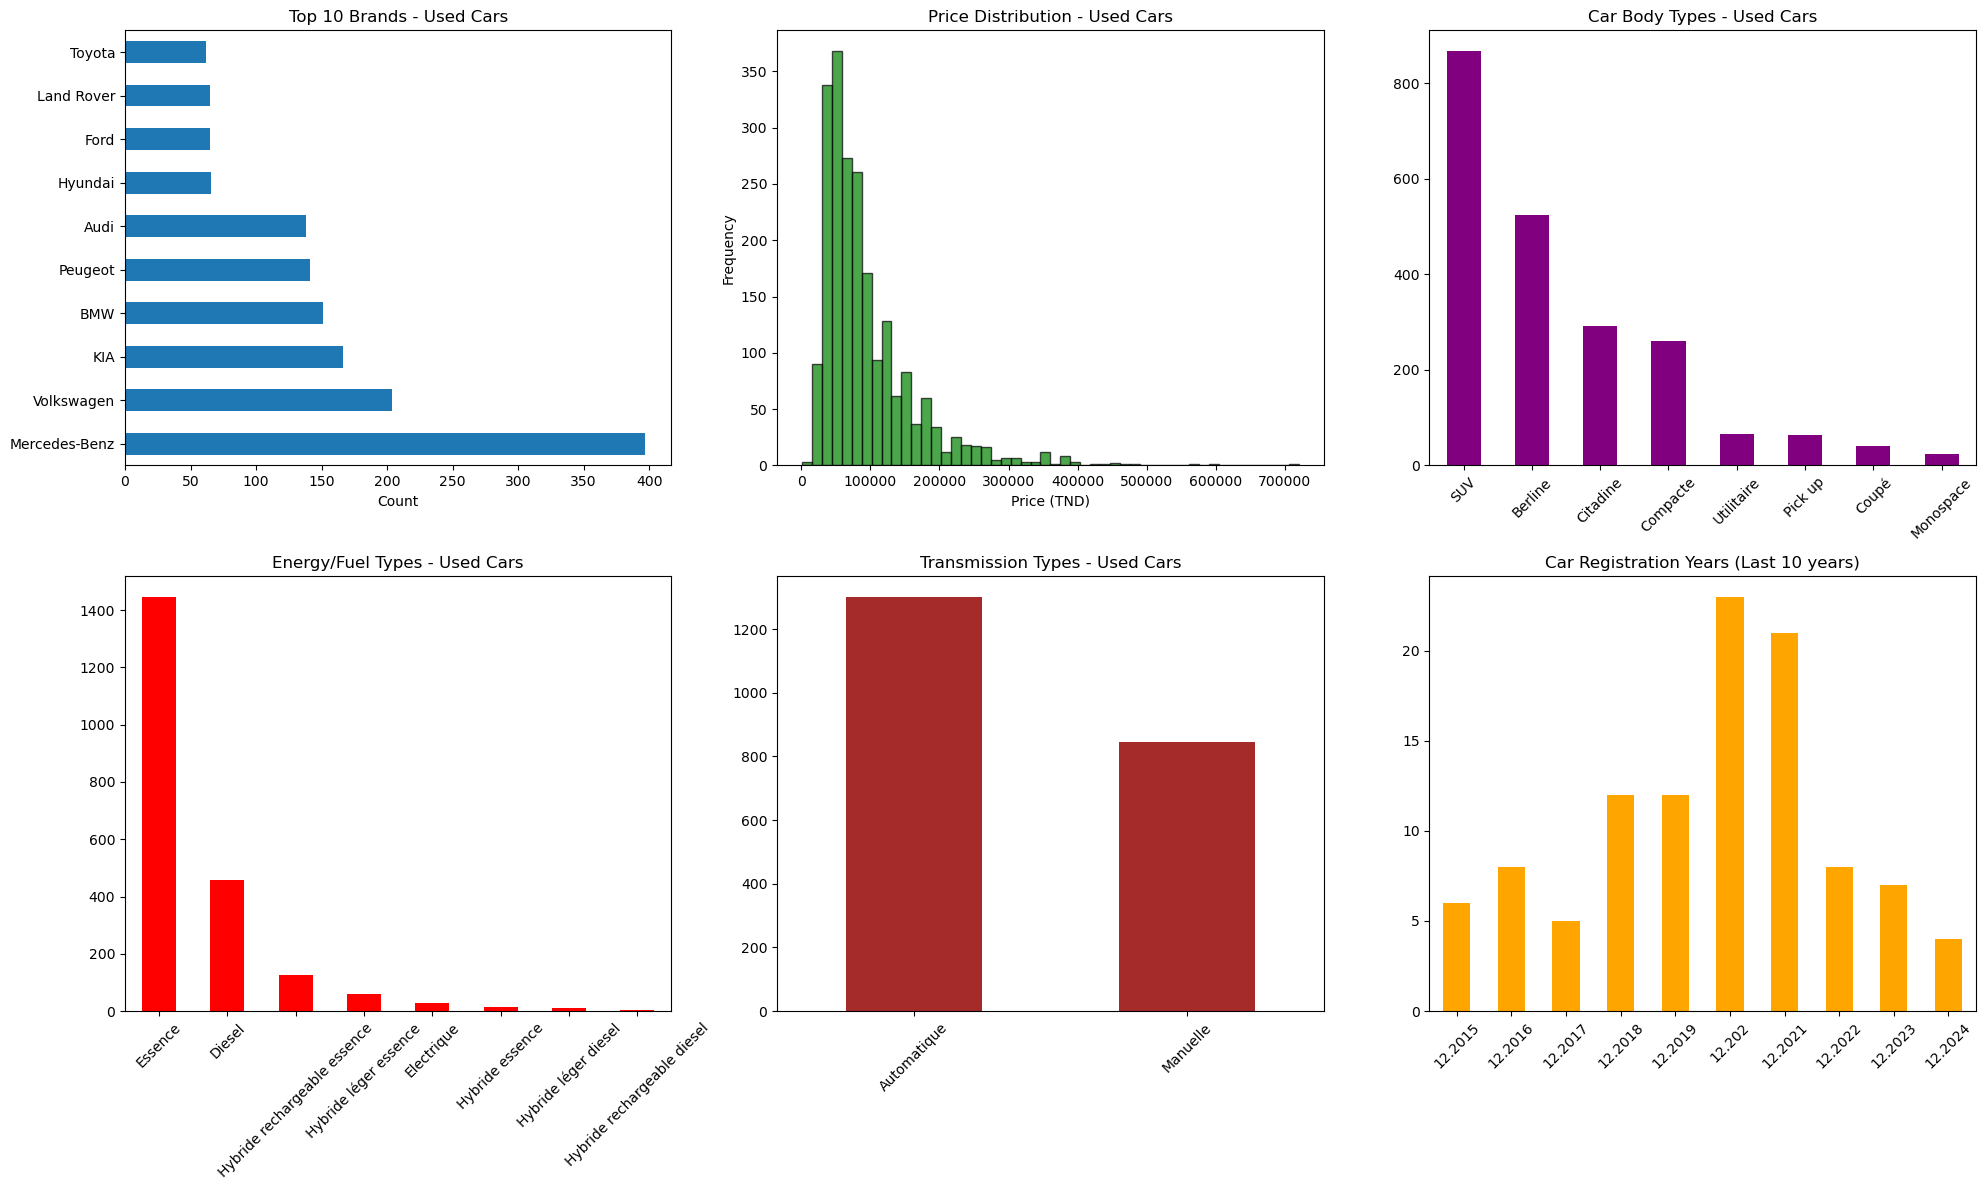

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
#Used Cars Visualizations

# 1. Brand Distribution -
plt.subplot(2, 3, 1)
brand_counts_used = df_used['Spécifications - Marque'].value_counts().head(10)
brand_counts_used.plot(kind='barh')
plt.title('Top 10 Brands - Used Cars')
plt.xlabel('Count')

# 2. Price Distribution
plt.subplot(2, 3, 2)
plt.hist(df_used['Price'], bins=50, alpha=0.7, edgecolor='black', color='green')
plt.title('Price Distribution - Used Cars')
plt.xlabel('Price (TND)')
plt.ylabel('Frequency')

# 3. Car Body Types
plt.subplot(2, 3, 3)
body_type_counts = df_used['Spécifications - Carrosserie'].value_counts().head(8)
body_type_counts.plot(kind='bar', color='purple')
plt.title('Car Body Types - Used Cars')
plt.xticks(rotation=45)

# 4. Energy/Fuel Types 
plt.subplot(2, 3, 4)
energy_counts = df_used['Motorisation - Énergie'].value_counts().head(8)
energy_counts.plot(kind='bar', color='red')
plt.title('Energy/Fuel Types - Used Cars')
plt.xticks(rotation=45)

# 5. Transmission Types 
plt.subplot(2, 3, 5)
transmission_counts = df_used['Boite vitesse'].value_counts().head(6)
transmission_counts.plot(kind='bar', color='brown')
plt.title('Transmission Types - Used Cars')
plt.xticks(rotation=45)

# 6. Year Distribution 
plt.subplot(2, 3, 6)
if 'Mise en circulation' in df_used.columns:
    year_counts = df_used['Mise en circulation'].value_counts().sort_index().tail(10)
    year_counts.plot(kind='bar', color='orange')
    plt.title('Car Registration Years (Last 10 years)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# now the same but for new cars

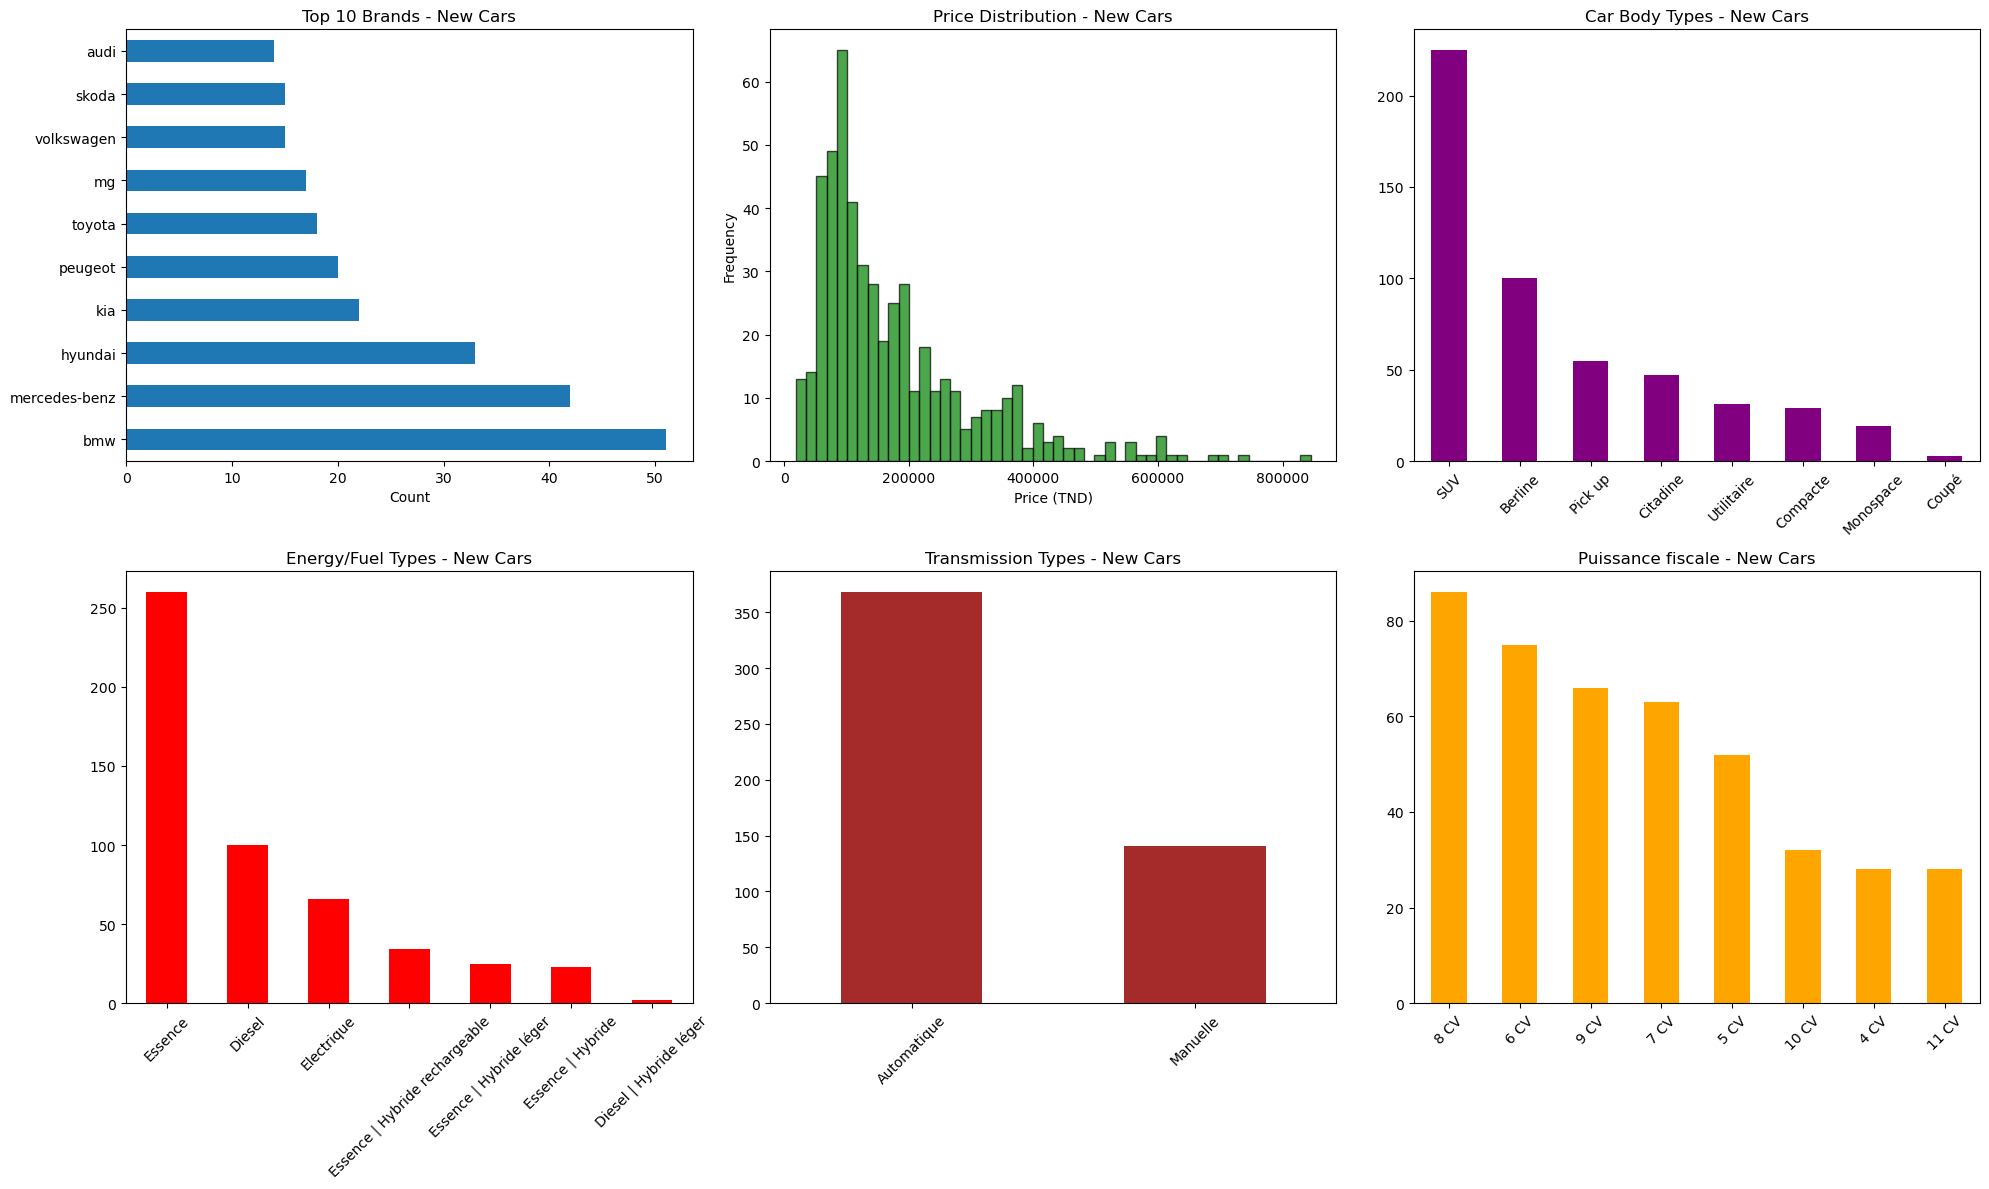

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Convert price to float for new cars
df_new['Price_float'] = df_new['Price'].str.replace(' ', '').astype(float)

# 1. Brand Distribution 
plt.subplot(2, 3, 1)
brand_counts_new = df_new['Brand'].value_counts().head(10)
brand_counts_new.plot(kind='barh')
plt.title('Top 10 Brands - New Cars')
plt.xlabel('Count')

# 2. Price Distribution 
plt.subplot(2, 3, 2)
plt.hist(df_new['Price_float'], bins=50, alpha=0.7, edgecolor='black', color='green')
plt.title('Price Distribution - New Cars')
plt.xlabel('Price (TND)')
plt.ylabel('Frequency')

# 3. Car Body Types
plt.subplot(2, 3, 3)
body_type_counts_new = df_new['Carrosserie'].value_counts().head(8)
body_type_counts_new.plot(kind='bar', color='purple')
plt.title('Car Body Types - New Cars')
plt.xticks(rotation=45)

# 4. Energy/Fuel Types 
plt.subplot(2, 3, 4)
energy_counts_new = df_new['Energie'].value_counts().head(8)
energy_counts_new.plot(kind='bar', color='red')
plt.title('Energy/Fuel Types - New Cars')
plt.xticks(rotation=45)

# 5. Transmission Types
plt.subplot(2, 3, 5)
transmission_counts_new = df_new['Boîte'].value_counts().head(6)
transmission_counts_new.plot(kind='bar', color='brown')
plt.title('Transmission Types - New Cars')
plt.xticks(rotation=45)

# 6. Puissance fiscale Distribution 
plt.subplot(2, 3, 6)
if 'Puissance fiscale' in df_new.columns:
    cylinder_counts = df_new['Puissance fiscale'].value_counts().head(8)
    cylinder_counts.plot(kind='bar', color='orange')
    plt.title('Puissance fiscale - New Cars')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Now let's have a look at the data quality  

In [22]:
def comprehensive_data_quality_report(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"COMPREHENSIVE DATA QUALITY REPORT: {dataset_name}")
    print(f"{'='*60}")
    
    # Basic Information
    print(f"Dataset Shape: {df.shape}")
    print(f"Total Records: {len(df):,}")
    print(f"Total Features: {len(df.columns)}")
    print(f"Duplicate Rows: {df.duplicated().sum()} ({(df.duplicated().sum()/len(df))*100:.2f}%)")
    
    # Data Types Analysis
    print(f"\nDATA TYPES DISTRIBUTION:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   {dtype}: {count} columns")
    
    # Missing Values Analysis
    print(f"\nMISSING VALUES ANALYSIS:")
    missing_stats = df.isnull().sum()
    missing_percent = (missing_stats / len(df)) * 100
    
    print(f"   Columns with no missing values: {len(missing_stats[missing_stats == 0])}")
    print(f"   Columns with <5% missing: {len(missing_percent[missing_percent < 5])}")
    print(f"   Columns with 5-20% missing: {len(missing_percent[(missing_percent >= 5) & (missing_percent < 20)])}")
    print(f"   Columns with 20-50% missing: {len(missing_percent[(missing_percent >= 20) & (missing_percent < 50)])}")
    print(f"   Columns with >50% missing: {len(missing_percent[missing_percent >= 50])}")
    
    # Top 10 columns with most missing values
    print(f"\nTOP 10 COLUMNS WITH MOST MISSING VALUES:")
    missing_top10 = missing_percent.sort_values(ascending=False).head(10)
    for col, percent in missing_top10.items():
        print(f"   {col}: {percent:.1f}%")
    
    return missing_percent

# Generate reports for both datasets
print("COMPREHENSIVE DATA QUALITY ASSESSMENT")
missing_new = comprehensive_data_quality_report(df_new, "NEW CARS")
missing_used = comprehensive_data_quality_report(df_used, "USED CARS")

COMPREHENSIVE DATA QUALITY ASSESSMENT

COMPREHENSIVE DATA QUALITY REPORT: NEW CARS
Dataset Shape: (510, 167)
Total Records: 510
Total Features: 167
Duplicate Rows: 1 (0.20%)

DATA TYPES DISTRIBUTION:
   object: 132 columns
   float64: 34 columns
   int64: 1 columns

MISSING VALUES ANALYSIS:
   Columns with no missing values: 18
   Columns with <5% missing: 28
   Columns with 5-20% missing: 12
   Columns with 20-50% missing: 14
   Columns with >50% missing: 113

TOP 10 COLUMNS WITH MOST MISSING VALUES:
   Cloison entre cabine et compartiment arrière: 100.0%
   Boulons de roues protégés: 100.0%
   Voiture populaire: 100.0%
   Préparation pour téléphone: 100.0%
   Allumage automatique des feux: 100.0%
   Lave Phares: 100.0%
   Détection des piétons: 100.0%
   Fixations ISOFIX: 100.0%
   Pack Sport Chrono: 100.0%
   Anti-démarrage électronique: 100.0%

COMPREHENSIVE DATA QUALITY REPORT: USED CARS
Dataset Shape: (2148, 99)
Total Records: 2,148
Total Features: 99
Duplicate Rows: 2 (0.09%)

D

# Data Quality Assessment Summary

## Dataset Comparison

### New Cars Dataset
- **Size**: 510 records with 167 features
- **Data Types**: Primarily categorical (131 object columns)
- **Critical Issue**: Severe missing data problem
  - 113 columns (68%) have >50% missing values
  - Only 18 columns have complete data
  - 10 columns are completely empty (100% missing)
- **Duplicates**: Minimal (1 duplicate row)

### Used Cars Dataset
- **Size**: 2,148 records with 99 features
- **Data Types**: Mostly categorical (97 object columns)
- **Data Quality**: Excellent
  - 97 columns have no missing values
  - Only 2 columns have minimal missing data (<2.5%)
  - No columns with significant missing data
- **Duplicates**: Very few (2 duplicate rows)


# now we'll do price analysis and outliers detection

In [23]:
def analyze_prices(df, dataset_name, price_col='Price'):
    print(f"\n  PRICE ANALYSIS: {dataset_name}")
    print(f"{'-'*40}")
    
    # Convert price if needed (new cars)
    if df[price_col].dtype == 'object':
        df[price_col] = df[price_col].str.replace(' ', '').astype(float)
    
    prices = df[price_col]
    
    # Basic stats
    print(f" Price Statistics:")
    print(f"   Mean: {prices.mean():,.0f} TND")
    print(f"   Median: {prices.median():,.0f} TND")
    print(f"   Min: {prices.min():,.0f} TND")
    print(f"   Max: {prices.max():,.0f} TND")
    print(f"   Std: {prices.std():,.0f} TND")
    
    # Outlier detection
    Q1 = prices.quantile(0.25)
    Q3 = prices.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = prices[(prices < lower_bound) | (prices > upper_bound)]
    print(f"\n  Outlier Analysis:")
    print(f"   Lower bound: {lower_bound:,.0f} TND")
    print(f"   Upper bound: {upper_bound:,.0f} TND")
    print(f"   Number of outliers: {len(outliers)} ({len(outliers)/len(prices)*100:.1f}%)")
    
    return prices, outliers

# Analyze prices for both datasets
prices_new, outliers_new = analyze_prices(df_new, "NEW CARS", 'Price')
prices_used, outliers_used = analyze_prices(df_used, "USED CARS", 'Price')


  PRICE ANALYSIS: NEW CARS
----------------------------------------
 Price Statistics:
   Mean: 177,226 TND
   Median: 130,840 TND
   Min: 18,264 TND
   Max: 845,000 TND
   Std: 132,274 TND

  Outlier Analysis:
   Lower bound: -131,834 TND
   Upper bound: 446,941 TND
   Number of outliers: 24 (4.7%)

  PRICE ANALYSIS: USED CARS
----------------------------------------
 Price Statistics:
   Mean: 93,731 TND
   Median: 73,000 TND
   Min: 1,111 TND
   Max: 720,000 TND
   Std: 69,683 TND

  Outlier Analysis:
   Lower bound: -57,375 TND
   Upper bound: 223,625 TND
   Number of outliers: 123 (5.7%)


## Key Insights from the output
1. Clear price premium for new vehicles
2. Used car market shows more price consistency
3. Both markets contain significant high-end premium vehicles
4. Outlier treatment will be necessary for robust modeling

# finally we'll do a relations and correlation analysis

In [24]:
def analyze_feature_relationships(df, dataset_name, target_col='Price'):
    print(f"\nFEATURE RELATIONSHIPS: {dataset_name}")
    print("-" * 40)

    if df[target_col].dtype == 'object':
        df[target_col] = df[target_col].str.replace(" ", "").astype(float)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    df_num = df[num_cols].copy().dropna(axis=1, how="all")
    df_num = df_num.fillna(df_num.median(numeric_only=True))

    cor = df_num.corr()[target_col].drop(target_col).dropna()

    positives = cor[cor > 0].sort_values(ascending=False)
    negatives = cor[cor < 0].sort_values(ascending=True)

    print("\nTop positive correlations:")
    for f, c in positives.head(10).items():
        print(f"   {f}: {c:.3f}")

    print("\nTop negative correlations:")
    if len(negatives) == 0:
        print("   (none)")
    else:
        for f, c in negatives.head(10).items():
            print(f"   {f}: {c:.3f}")

    return num_cols



print("FEATURE RELATIONSHIP ANALYSIS")
numerical_new = analyze_feature_relationships(df_new, "NEW CARS")
numerical_used = analyze_feature_relationships(df_used, "USED CARS")


FEATURE RELATIONSHIP ANALYSIS

FEATURE RELATIONSHIPS: NEW CARS
----------------------------------------

Top positive correlations:
   Price_float: 1.000
   Nombre de cylindres: 0.468
   Nombre de rapports: 0.379
   Nombre de moteurs électriques: 0.322
   Nombre de places: 0.186

Top negative correlations:
   (none)

FEATURE RELATIONSHIPS: USED CARS
----------------------------------------

Top positive correlations:

Top negative correlations:
   Mise en circulation: -0.008



## Dataset Overview

### New Cars Dataset
- **Size**: 510 records, 167 features
- **Data Types**: 131 categorical (object), 36 numerical
- **Critical Issue**: Severe data sparsity - 113 columns (68%) have >50% missing values
- **Price Range**: 18,264 to 845,000 TND (Mean: 177,226 TND)

### Used Cars Dataset  
- **Size**: 2,148 records, 99 features
- **Data Types**: 97 categorical (object), 2 numerical
- **Data Quality**: Excellent - 97/99 columns have no missing values
- **Price Range**: 1,111 to 720,000 TND (Mean: 93,731 TND)

## Key Findings

### Data Quality Assessment
- **New Cars**: Requires aggressive feature reduction
- **Used Cars**: Ready for immediate analysis with minimal preprocessing
- **Duplicates**: Minimal in both datasets (<1%)

### Price Analysis
- **Price Difference**: New cars are 89% more expensive on average than used cars
- **Price Distribution**: Both datasets show right-skewed distributions
- **Outliers**: Moderate presence (4.7% new, 5.7% used) requiring treatment

### Feature Relationships
- **New Cars**: Limited numerical correlations found
  - Positive: Cylinders (0.47), Gears (0.38), Electric motors (0.32)
- **Used Cars**: Very few numerical features available
  - Registration year shows near-zero correlation (-0.008)

## Critical Issues Identified

1. **New Cars Data Sparsity**: 68% of features unusable due to missing data
2. **Limited Numerical Features**: Both datasets dominated by categorical data
4. **Data Type Inconsistency**: Price stored as string in new cars dataset


###  required actions for next phase
1. **New Cars**: Remove  columns that have a lot of missing values
2. **Price Conversion**: Convert new car prices from string to numerical
3. **Outlier Treatment**: eliminate outliers in both datasets



# Tayara.tn Dataset Analysis

## Data Source

**Source:** https://www.tayara.tn

## Data Collection Scope

Comprehensive web scraping of used car listings from Tayara marketplace:
- Price range: 8,000 - 300,000 TND
- Scraped from around 149 listing pages
- Focus on listings with both Brand (Marque) and Model (Modèle) information

In [25]:
# Load Tayara dataset
df_tayara = pd.read_csv("../data_scraper/data_scraped/tayara_cars.csv")

First let's check the structure/dimensions of the Tayara dataset along with general information

In [26]:
print("=== TAYARA CARS DATASET ===")
print(f"Shape: {df_tayara.shape}")
print("\nInfo:")
print(df_tayara.info())
print("\nFirst few rows:")
print(df_tayara.head())

=== TAYARA CARS DATASET ===
Shape: (4029, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4029 entries, 0 to 4028
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marque               4029 non-null   object 
 1   Modèle               4029 non-null   object 
 2   Price                4029 non-null   int64  
 3   Puissance fiscale    3689 non-null   float64
 4   Carburant            3978 non-null   object 
 5   Boite                3963 non-null   object 
 6   Kilométrage          3890 non-null   float64
 7   Type de carrosserie  3626 non-null   object 
 8   Année                3903 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 283.4+ KB
None

First few rows:
          Marque             Modèle   Price  Puissance fiscale Carburant  \
0  Mercedes-Benz         Classe CLA   85000                7.0   Essence   
1            BMW            Serie 3   52500           

Now we'll check for basic stats, column names, and missing values

In [27]:
# Check for missing values
print("\n=== MISSING VALUES - TAYARA ===")
print(df_tayara.isnull().sum().sort_values(ascending=False))

# Basic statistics
print("\n=== BASIC STATISTICS - TAYARA ===")
print(df_tayara.describe(include='all'))

# Check column names
print("\n=== COLUMNS - TAYARA ===")
print("Tayara columns:", df_tayara.columns.tolist())


=== MISSING VALUES - TAYARA ===
Type de carrosserie    403
Puissance fiscale      340
Kilométrage            139
Année                  126
Boite                   66
Carburant               51
Marque                   0
Modèle                   0
Price                    0
dtype: int64

=== BASIC STATISTICS - TAYARA ===
            Marque Modèle          Price  Puissance fiscale Carburant  \
count         4029   4029    4029.000000       3.689000e+03      3978   
unique          53    418            NaN                NaN         6   
top     Volkswagen   Clio            NaN                NaN   Essence   
freq           525    150            NaN                NaN      2716   
mean           NaN    NaN   51266.818565       1.131991e+05       NaN   
std            NaN    NaN   37241.917060       3.763338e+06       NaN   
min            NaN    NaN    8200.000000      -1.000000e+01       NaN   
25%            NaN    NaN   27500.000000       5.000000e+00       NaN   
50%            NaN 

# Tayara Dataset Visualizations

## Key Metrics
- Brand distribution
- Price distribution
- Body types (Type de carrosserie)
- Fuel types (Carburant)
- Transmission (Boite)
- Year distribution (Année)

2008     98
2009    110
2010    176
2011    165
2012    144
2013    157
2014    181
2015    174
2016    182
2017    257
2018    238
2019    222
2020    315
2021    375
2022    289
2023    126
2024     54
2025     36
Name: Année, dtype: int64


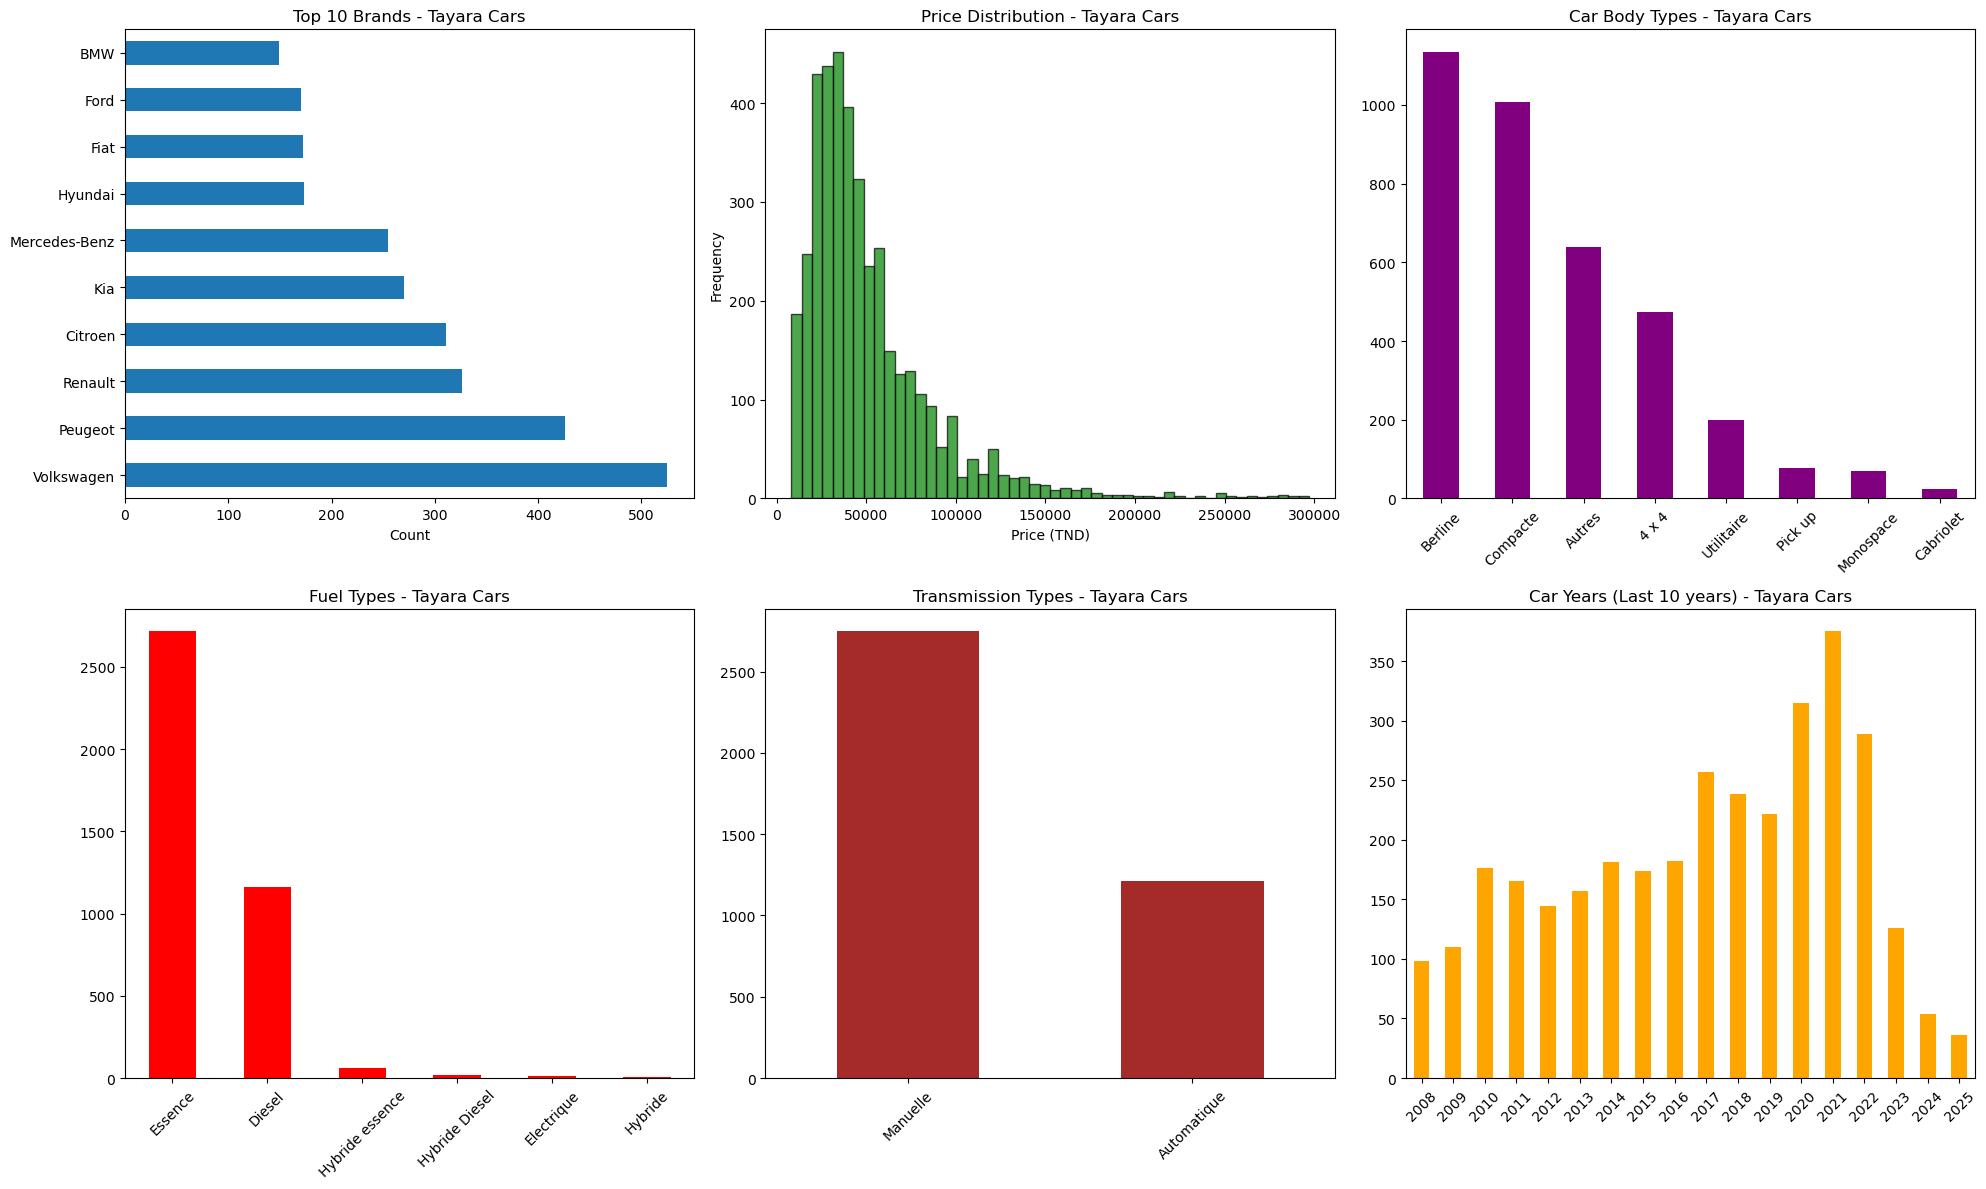

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Convert Price to numeric
df_tayara['Price'] = pd.to_numeric(df_tayara['Price'], errors='coerce')

# 1. Brand Distribution
plt.subplot(2, 3, 1)
brand_counts_tayara = df_tayara['Marque'].value_counts().head(10)
brand_counts_tayara.plot(kind='barh')
plt.title('Top 10 Brands - Tayara Cars')
plt.xlabel('Count')

# 2. Price Distribution
plt.subplot(2, 3, 2)
plt.hist(df_tayara['Price'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='green')
plt.title('Price Distribution - Tayara Cars')
plt.xlabel('Price (TND)')
plt.ylabel('Frequency')

# 3. Car Body Types
plt.subplot(2, 3, 3)
if 'Type de carrosserie' in df_tayara.columns:
    body_type_counts_tayara = df_tayara['Type de carrosserie'].value_counts().head(8)
    body_type_counts_tayara.plot(kind='bar', color='purple')
    plt.title('Car Body Types - Tayara Cars')
    plt.xticks(rotation=45)

# 4. Fuel Types
plt.subplot(2, 3, 4)
if 'Carburant' in df_tayara.columns:
    fuel_counts_tayara = df_tayara['Carburant'].value_counts().head(8)
    fuel_counts_tayara.plot(kind='bar', color='red')
    plt.title('Fuel Types - Tayara Cars')
    plt.xticks(rotation=45)

# 5. Transmission Types
plt.subplot(2, 3, 5)
if 'Boite' in df_tayara.columns:
    transmission_counts_tayara = df_tayara['Boite'].value_counts().head(6)
    transmission_counts_tayara.plot(kind='bar', color='brown')
    plt.title('Transmission Types - Tayara Cars')
    plt.xticks(rotation=45)

# 6. Year Distribution
plt.subplot(2, 3, 6)
if 'Année' in df_tayara.columns:
    years = pd.to_numeric(df_tayara['Année'], errors='coerce')
    
    valid_years = years[(years > 1990) & (years <= 2025)]
    
    valid_years = valid_years.astype(int)
    
    year_counts_tayara = valid_years.value_counts().sort_index().tail(18)
    year_counts_tayara.plot(kind='bar', color='orange')
    plt.title('Car Years (Last 10 years) - Tayara Cars')
    plt.xticks(rotation=45)
    print(year_counts_tayara)



plt.tight_layout()
plt.show()

## Now let's assess the data quality for Tayara dataset

In [29]:
# Generate data quality report for Tayara
missing_tayara = comprehensive_data_quality_report(df_tayara, "TAYARA CARS")


COMPREHENSIVE DATA QUALITY REPORT: TAYARA CARS
Dataset Shape: (4029, 9)
Total Records: 4,029
Total Features: 9
Duplicate Rows: 114 (2.83%)

DATA TYPES DISTRIBUTION:
   object: 5 columns
   float64: 3 columns
   int64: 1 columns

MISSING VALUES ANALYSIS:
   Columns with no missing values: 3
   Columns with <5% missing: 7
   Columns with 5-20% missing: 2
   Columns with 20-50% missing: 0
   Columns with >50% missing: 0

TOP 10 COLUMNS WITH MOST MISSING VALUES:
   Type de carrosserie: 10.0%
   Puissance fiscale: 8.4%
   Kilométrage: 3.4%
   Année: 3.2%
   Boite: 1.6%
   Carburant: 1.3%
   Marque: 0.0%
   Modèle: 0.0%
   Price: 0.0%


# Price analysis and outliers detection for Tayara

In [30]:
# Analyze prices for Tayara dataset
prices_tayara, outliers_tayara = analyze_prices(df_tayara, "TAYARA CARS", 'Price')


  PRICE ANALYSIS: TAYARA CARS
----------------------------------------
 Price Statistics:
   Mean: 51,267 TND
   Median: 40,300 TND
   Min: 8,200 TND
   Max: 297,000 TND
   Std: 37,242 TND

  Outlier Analysis:
   Lower bound: -25,750 TND
   Upper bound: 116,250 TND
   Number of outliers: 245 (6.1%)


# Feature relationships and correlation analysis for Tayara

In [31]:
# Feature relationship analysis for Tayara
numerical_tayara = analyze_feature_relationships(df_tayara, "TAYARA CARS")


FEATURE RELATIONSHIPS: TAYARA CARS
----------------------------------------

Top positive correlations:
   Année: 0.015

Top negative correlations:
   Puissance fiscale: -0.028
   Kilométrage: -0.016


# Tayara Dataset Summary

## Dataset Overview

### Size and Structure
- **Records**: Variable (scraped from 150 pages)
- **Features**: 9 core features (Marque, Modèle, Price, Puissance fiscale, Carburant, Boite, Kilométrage, Type de carrosserie, Année)
- **Data Types**: Mix of categorical and numerical features
- **Source**: Tayara.tn  listings

## Key Characteristics

### Data Quality
- Clean, structured data from marketplace listings
- All records guaranteed to have Marque and Modèle (filtering criteria during scraping)
- Price range pre-filtered: 8,000 - 300,000 TND

### Price Analysis
- Focused on mid-range used car market
- More accessible price points compared to automobile.tn
- Representative of typical consumer marketplace

### Feature Availability
- **Always Present**: Marque, Modèle (by design)
- **Commonly Present**: Price, Année, Carburant, Boite
- **Sometimes Present**: Kilométrage, Type de carrosserie, Puissance fiscale


## Limitations
1. Variable data completeness across features
2. Seller-reported data (potential accuracy issues)
3. Limited to price range 8,000 - 300,000 TND
4. No technical specifications beyond basic features